In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import cifar10

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# y passe de (50000,1) -> (50000,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Train :", x_train.shape)
print("Test :", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train : (50000, 32, 32, 3)
Test : (10000, 32, 32, 3)


In [ ]:
x_train = x_train.reshape(len(x_train), -1)
x_test = x_test.reshape(len(x_test), -1)

print("Après flatten :", x_train.shape)

Après flatten : (50000, 3072)


In [ ]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

# IMPORTANT :
# on applique seulement transform sur le test
x_test_scaled = scaler.transform(x_test)

In [ ]:
pca = PCA(n_components=200)

x_train_pca = pca.fit_transform(x_train_scaled)

# pareil : seulement transform
x_test_pca = pca.transform(x_test_scaled)

print("Après PCA :", x_train_pca.shape)

Après PCA : (50000, 200)


In [ ]:
model = LogisticRegression(
    max_iter=300,
    solver="saga",
    multi_class="multinomial",
    n_jobs=-1
)

In [ ]:
start = time.time()

model.fit(x_train_pca, y_train)

training_time = time.time() - start

print(f"\nTemps entraînement : {training_time:.2f} secondes")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Temps entraînement : 23.12 secondes


In [ ]:
y_pred = model.predict(x_test_pca)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)

print("\nClassification Report :")
print(classification_report(y_test, y_pred))



Accuracy : 0.4102

Classification Report :
              precision    recall  f1-score   support

           0       0.44      0.48      0.46      1000
           1       0.46      0.48      0.47      1000
           2       0.31      0.27      0.29      1000
           3       0.31      0.28      0.29      1000
           4       0.37      0.29      0.33      1000
           5       0.34      0.34      0.34      1000
           6       0.41      0.51      0.46      1000
           7       0.46      0.44      0.45      1000
           8       0.49      0.53      0.51      1000
           9       0.46      0.47      0.46      1000

    accuracy                           0.41     10000
   macro avg       0.41      0.41      0.41     10000
weighted avg       0.41      0.41      0.41     10000



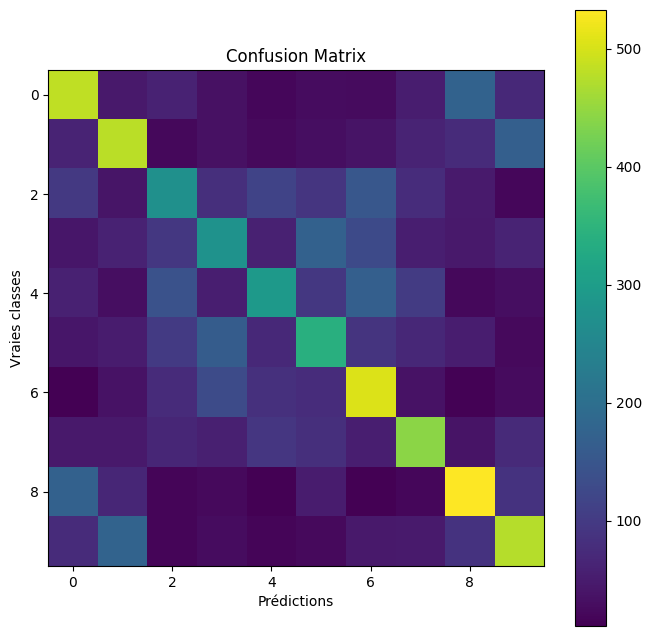

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Prédictions")

plt.ylabel("Vraies classes")

plt.colorbar()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, log_loss

# Prédictions classes
train_pred = model.predict(x_train_pca)
test_pred = model.predict(x_test_pca)

# Probabilités (nécessaires pour la loss)
train_proba = model.predict_proba(x_train_pca)
test_proba = model.predict_proba(x_test_pca)

# Accuracy
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

# Loss
train_loss = log_loss(y_train, train_proba)
test_loss = log_loss(y_test, test_proba)

# Affichage
print("\n===== RESULTATS =====")

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")

print(f"Train Loss     : {train_loss:.4f}")
print(f"Test Loss      : {test_loss:.4f}")


===== RESULTATS =====
Train Accuracy : 0.4258
Test Accuracy  : 0.4102
Train Loss     : 1.6857
Test Loss      : 1.7137
